In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

In [37]:
bitcoin_df = pd.read_csv('bitcoin-price.csv')
market_df = pd.read_csv('market-data.csv')
onchain_df = pd.read_csv('on-chain-data.csv')

bitcoin_df['Date'] = pd.to_datetime(bitcoin_df['Datetime']).dt.date
market_df['Date'] = pd.to_datetime(market_df['Dates']).dt.date
onchain_df['Date'] = pd.to_datetime(onchain_df['Datetime']).dt.date

bitcoin_close = bitcoin_df[['Date', 'Close']].copy()
print(f"Bitcoin date range: {bitcoin_close['Date'].min()} to {bitcoin_close['Date'].max()}")
print(f"Market date range: {market_df['Date'].min()} to {market_df['Date'].max()}")
print(f"On-chain date range: {onchain_df['Date'].min()} to {onchain_df['Date'].max()}")

Bitcoin date range: 2009-01-03 to 2025-06-10
Market date range: 2017-01-02 to 2025-06-23
On-chain date range: 2019-03-30 to 2025-06-09


In [87]:
market_df_clean = market_df.drop(columns=['Dates'])
bitcoin_market_df = pd.merge(bitcoin_close, market_df_clean, on='Date', how='inner')
bitcoin_market_df = bitcoin_market_df.dropna()
bitcoin_market_df = bitcoin_market_df.rename(columns={'Close': 'Bitcoin Close'})

print(f"Shape: {bitcoin_market_df.shape}")
print(f"Date range: {bitcoin_market_df['Date'].min()} to {bitcoin_market_df['Date'].max()}")
print(f"Columns: {list(bitcoin_market_df.columns)}")
bitcoin_market_df.head()

Shape: (2202, 13)
Date range: 2017-01-02 to 2025-06-10
Columns: ['Date', 'Bitcoin Close', 'SPX Index', 'CCMP Index', 'INDU Index', 'XAU Curncy', 'CL1 Comdty', 'XAG Curncy', 'LMCADY Comdty', 'NG1 Comdty', 'DXY Curncy', 'EURUSD Curncy', 'USDCNY Curncy']


,Date,Bitcoin Close,SPX Index,CCMP Index,INDU Index,XAU Curncy,CL1 Comdty,XAG Curncy,LMCADY Comdty,NG1 Comdty,DXY Curncy,EURUSD Curncy,USDCNY Curncy
0,2025-06-10,108923.014410,6038.81,19714.99,42866.87,3323.69,64.98,36.5350,9840.60,3.533,99.098,1.1425,7.1878
1,2025-06-09,110303.871227,6005.88,19591.24,42761.76,3326.19,65.29,36.7584,9888.78,3.635,98.939,1.1422,7.1794
2,2025-06-06,104406.924809,6000.36,19529.95,42762.87,3310.42,64.58,35.9777,9762.84,3.784,99.190,1.1397,7.1926
3,2025-06-05,101613.260806,5939.30,19298.45,42319.74,3352.65,63.37,35.6510,9832.65,3.677,98.741,1.1445,7.1777
4,2025-06-04,104724.591994,5970.81,19460.49,42427.74,3372.72,62.85,34.5045,9669.98,3.716,98.787,1.1417,7.1780


In [90]:
onchain_df_clean = onchain_df.drop(columns=['Datetime'])
bitcoin_onchain_df = pd.merge(bitcoin_close, onchain_df_clean, on='Date', how='inner')
bitcoin_onchain_df = bitcoin_onchain_df.dropna()
bitcoin_onchain_df = bitcoin_onchain_df.rename(columns={'Close': 'Bitcoin Close'})

print(f"Shape: {bitcoin_onchain_df.shape}")
print(f"Date range: {bitcoin_onchain_df['Date'].min()} to {bitcoin_onchain_df['Date'].max()}")
print(f"Columns: {list(bitcoin_onchain_df.columns)}")
bitcoin_onchain_df.head()

Shape: (2264, 14)
Date range: 2019-03-30 to 2025-06-09
Columns: ['Date', 'Bitcoin Close', 'Active Addresses', 'Exchange Reserve', 'Exchange Netflow', 'Fee-Reward Ratio', 'Funding Rates', 'Hashrate', 'Mean Coin Age', 'Miner Reserve', 'MVRV Ratio', 'Open Interest', 'Puell Multiple', 'SOPR']


,Date,Bitcoin Close,Active Addresses,Exchange Reserve,Exchange Netflow,Fee-Reward Ratio,Funding Rates,Hashrate,Mean Coin Age,Miner Reserve,MVRV Ratio,Open Interest,Puell Multiple,SOPR
0,2025-06-09,110303.871227,893460.0,2.502490e+06,-3127.633553,0.011309,0.002927,8.837253e+11,1617.120227,1.808101e+06,2.340974,3.784251e+10,1.243001,1.013669
1,2025-06-08,105782.295477,779831.0,2.505618e+06,370.863428,0.006581,0.002124,9.657855e+11,1616.485453,1.807721e+06,2.247120,3.604954e+10,1.337595,1.011710
2,2025-06-07,105645.525274,787698.0,2.505247e+06,-1925.698528,0.007294,-0.000949,9.026623e+11,1615.764529,1.807631e+06,2.245429,3.601397e+10,1.245541,1.013583
3,2025-06-06,104406.924809,859500.0,2.507173e+06,-6228.992664,0.010475,-0.004703,8.458514e+11,1615.110946,1.807638e+06,2.220515,3.543465e+10,1.152875,1.006889
4,2025-06-05,101613.260806,866463.0,2.513402e+06,450.194966,0.011510,0.001402,8.458514e+11,1614.501350,1.807730e+06,2.162189,3.385101e+10,1.156797,1.002772


In [ ]:
market_numeric_cols = [col for col in bitcoin_market_df.columns if col != 'Date']
market_numeric_data = bitcoin_market_df[market_numeric_cols].select_dtypes(include=[np.number])
market_correlation_matrix = market_numeric_data.corr()

onchain_numeric_cols = [col for col in bitcoin_onchain_df.columns if col != 'Date']
onchain_numeric_data = bitcoin_onchain_df[onchain_numeric_cols].select_dtypes(include=[np.number])
onchain_correlation_matrix = onchain_numeric_data.corr()

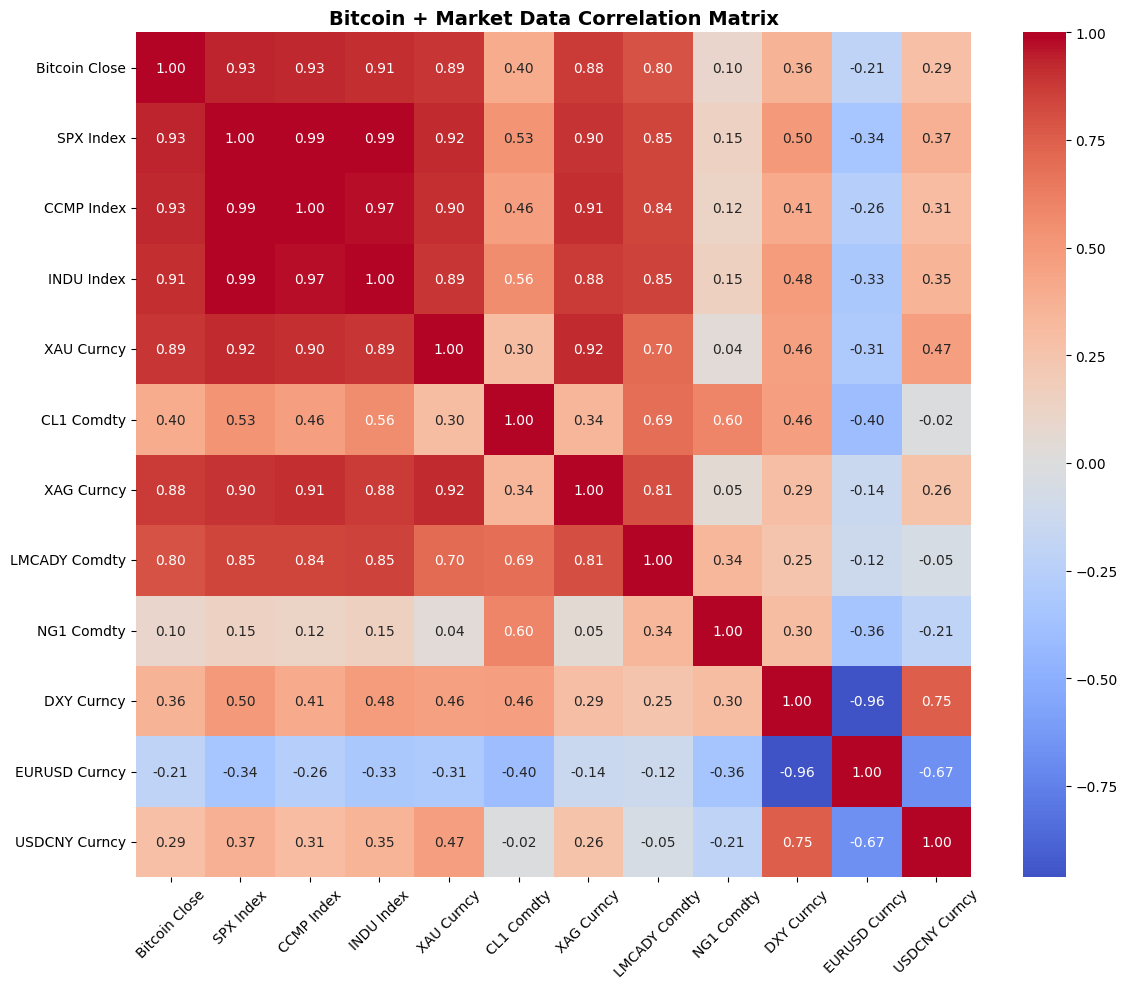

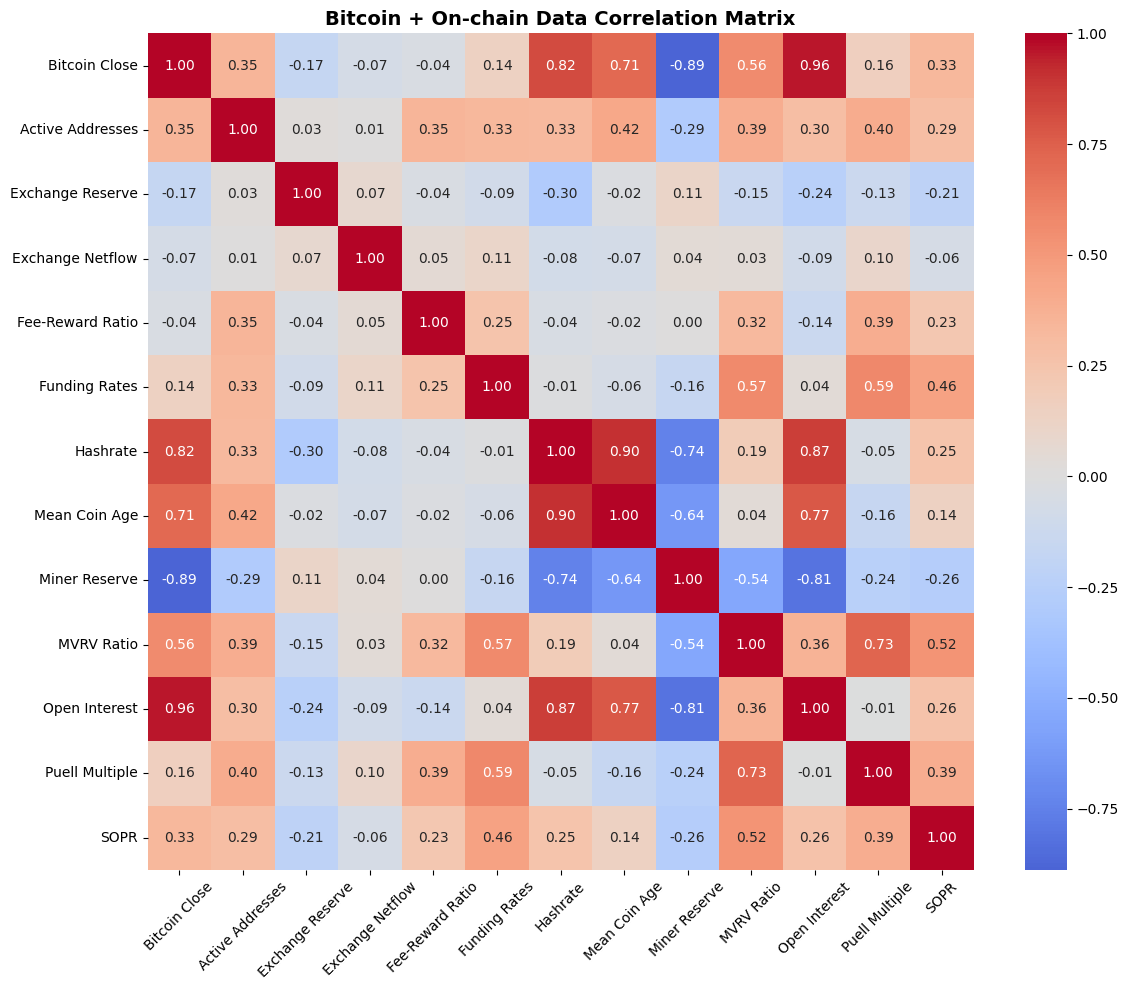

In [102]:
# Market Data Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(market_correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Bitcoin + Market Data Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# On-chain Data Correlation Heatmap  
plt.figure(figsize=(12, 10))
sns.heatmap(onchain_correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Bitcoin + On-chain Data Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
